# Myanmar Sign Language (MSL) Recognition for Emergency Domain - Version 1.0
## Runtime Environment: Local Machine (NVIDIA GeForce GTX 1060)

## Setup

In [1]:
import numpy as np

from pathlib import Path
from IPython.display import Image, display
from IPython.display import Video

In [2]:
ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
VIDEO_DIR = DATA_DIR / "videos"

SCRIPTS_DIR = ROOT / "scripts"
SRC_DIR = ROOT / "src"

RESULTS_DIR = ROOT / "results"

`00_setup_env.sh` is not run because the Conda environment is already set up.

## 1. Prepare Data

In [3]:
%cd {ROOT}

/home/lawun330/Desktop/myanmar-sign-language-recognition


In [4]:
!head -n 30 {DATA_DIR}/annotations.txt

မီး ။	မီး
မီး ငြှိမ်း ။	မီး ငြှိမ်း
မီးချိတ် ။	မီးချိတ်
မီးကပ် ။	မီးကပ်
ရေပုံး ။	ရေပုံး
သဲ အိတ် ။	အိတ် ထဲ သဲ
မီးသတ်ဆေးဘူး ။	အနီ ဘူး ဖြန်း
မီးသတ်ရေကန် ။	ကန် ထဲ ရေ သိမ်း
မီးလောင် လွယ် သော ပစ္စည်း များ ။	မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
လောင်စာဆီ ။	ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိုး
အမှိုက် ။	အမှိုက်
လျှပ်စစ် မီး ။	မီး လျှပ်စစ်
ဂက်စ် မီး ။	အဖြူ ဂက်စ်
မီးကြွင်းမီးကျန် ။	မီးကြွင်းမီးကျန်
မီးခလုပ် ။	ခလုပ် နှိပ်
မီးခြစ် ။	မီးခြစ်
ဖယောင်းတိုင် ။	ဖယောင်းတိုင်
ခြင်ဆေးခွေ ။	ခြင် ဆေးခွေ
အမွှေးတိုင် ။	အမွှေးတိုင်
မီးခိုး ။	မီး အခိုးအငွေ့ အမဲ
အောက်စီဂျင် ။	အောက်ဆီဂျင် o 2
ထွက်ပေါက် ။	ဆိုင်းဘုတ် အဲဒီက ပြေး တံခါးပေါက်
မီးသတ်ကား ။	ကား အရေးပေါ် မီးသတ်
မီးသတ်သမား ။	မီးသတ်သမား
မီးသတ်ဌာန ။	မီးသတ် အိမ် ထဲ
လျှပ်စစ် ဝါယာ ရှော့ ။	လျှပ်စစ် ကြိုး ရှော့
ရေဘေး ။	ရေ ကြီး
ဘေးအန္တရာယ် ။	သဘာဝ ဒုက္ခ
မြစ်ခေျာင်း ။	ရေ ချောင်း
မြေနိမ့်ဒေသ ။	မြေနိမ့် အဲ့နေရာ


In [5]:
# verify msl_gloss column is used as labels
!grep -n "'label':" {SRC_DIR}/utils.py

105:                'label':       msl_gloss,   # -- MODIFIED HERE --


In [6]:
!time {SCRIPTS_DIR}/01_prepare_data.sh

 Step 1 — Data Preparation
 Video dir       : data/videos
 Annotation file : data/annotations.txt

 Found 558 videos and 558 annotation lines

2026-06-16 20:01:11 | INFO     | prepare_data | ============================================================
2026-06-16 20:01:11 | INFO     | prepare_data | MSL Data Preparation
2026-06-16 20:01:11 | INFO     | prepare_data | ============================================================
2026-06-16 20:01:11 | INFO     | prepare_data | Parsing annotation file: data/annotations.txt
2026-06-16 20:01:11 | INFO     | prepare_data | Total annotation records: 558
2026-06-16 20:01:11 | INFO     | prepare_data | Vocabulary built: 541 unique classes
2026-06-16 20:01:11 | INFO     | prepare_data | Label map saved → data/label_map.json
2026-06-16 20:01:11 | INFO     | prepare_data | Matching videos from: data/videos

Dataset Statistics [full]
  Total samples    : 558
  Classes (present): 541 / 541 total
  Samples/class    : min=1, max=3, mean=1.03
  Size dist

In [7]:
!ls {DATA_DIR}

annotations.txt  kfold_splits.json  label_map.json  splits.json  videos


In [8]:
!cat {DATA_DIR}/label_map.json | head -n 30

{
  "label2idx": {
    "မီး": 0,
    "မီး ငြှိမ်း": 1,
    "မီးချိတ်": 2,
    "မီးကပ်": 3,
    "ရေပုံး": 4,
    "အိတ် ထဲ သဲ": 5,
    "အနီ ဘူး ဖြန်း": 6,
    "ကန် ထဲ ရေ သိမ်း": 7,
    "မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး": 8,
    "ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိုး": 9,
    "အမှိုက်": 10,
    "မီး လျှပ်စစ်": 11,
    "အဖြူ ဂက်စ်": 12,
    "မီးကြွင်းမီးကျန်": 13,
    "ခလုပ် နှိပ်": 14,
    "မီးခြစ်": 15,
    "ဖယောင်းတိုင်": 16,
    "ခြင် ဆေးခွေ": 17,
    "အမွှေးတိုင်": 18,
    "မီး အခိုးအငွေ့ အမဲ": 19,
    "အောက်ဆီဂျင် o 2": 20,
    "ဆိုင်းဘုတ် အဲဒီက ပြေး တံခါးပေါက်": 21,
    "ကား အရေးပေါ် မီးသတ်": 22,
    "မီးသတ်သမား": 23,
    "မီးသတ် အိမ် ထဲ": 24,
    "လျှပ်စစ် ကြိုး ရှော့": 25,
    "ရေ ကြီး": 26,
    "သဘာဝ ဒုက္ခ": 27,
cat: write error: Broken pipe


## 2. Extract Keypoints

In [9]:
!time {SCRIPTS_DIR}/02_extract_keypoints.sh

 Step 2 — MediaPipe Holistic Keypoint Extraction
 Video dir     : data/videos
 Output dir    : data/keypoints
 Complexity    : 2
 Overwrite     : false

 Total videos  : 558

I0000 00:00:1781619678.793591   28185 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781619678.812483   28356 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781619678.821873   28185 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1781619678.826260   28371 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
Extracting keypoints:   0%|          | 0/558 [00:00<?, ?video/s]W0000 00:00:1781619678.871355   28359 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disab

In [10]:
# check keypoints
!ls {DATA_DIR}/keypoints/* | head -n 10

/home/lawun330/Desktop/myanmar-sign-language-recognition/data/keypoints/extraction_stats.json

/home/lawun330/Desktop/myanmar-sign-language-recognition/data/keypoints/101-150:
idx20-101.npy
idx20-101_vis.npy
idx20-102.npy
idx20-102_vis.npy
idx20-103.npy
idx20-103_vis.npy
idx20-104.npy
ls: write error: Broken pipe


In [11]:
# check extraction stats
!cat {DATA_DIR}/keypoints/extraction_stats.json

{
  "total": 558,
  "processed": 558,
  "failed": 0,
  "skipped": 0,
  "seq_len_min": 50,
  "seq_len_max": 387,
  "seq_len_mean": 130.56810035842295,
  "seq_len_std": 55.11924044288601,
  "seq_len_p50": 119.0,
  "seq_len_p95": 241.14999999999998,
  "lh_mean_presence": 0.6177208780096964,
  "rh_mean_presence": 0.7129535191739758
}

In [12]:
# verify coordinate and visibility data
coords = np.load(f'{DATA_DIR}/keypoints/101-150/idx20-101.npy')
vis = np.load(f'{DATA_DIR}/keypoints/101-150/idx20-101_vis.npy')

# shape
print(f"--- Shapes ---")
print(f"Coordinates shape: {coords.shape}") # Expect: (frames, landmarks, 3)
print(f"Visibility shape:  {vis.shape}")    # Expect: (frames, landmarks)
print()

# data type
print("--- Data Types ---")
print(f"Coordinates dtype: {coords.dtype}")
print(f"Visibility dtype:  {vis.dtype}")
print()

# (x, y, z) for all landmarks in the first frame / time step
print(f"--- Sample Data (First Frame) ---")
print(f"\nFirst 3 landmark coordinates:\n{coords[0, :3, :]}") 
print(f"\nFirst 3 visibility scores:\n{vis[0, :3]}")

--- Shapes ---
Coordinates shape: (102, 75, 3)
Visibility shape:  (102, 33)

--- Data Types ---
Coordinates dtype: float32
Visibility dtype:  float32

--- Sample Data (First Frame) ---

First 3 landmark coordinates:
[[-0.01208273 -1.2015185  -1.534098  ]
 [ 0.06407156 -1.3612919  -1.3890448 ]
 [ 0.10239748 -1.3473412  -1.3915948 ]]

First 3 visibility scores:
[0.99353594 0.98042333 0.9800892 ]


## 3. Augment Data

In [13]:
!time {SCRIPTS_DIR}/03_augment_data.sh

 Step 3 — All-Class Offline Data Augmentation
 Strategy    : all 558 videos → train/val/test by aug type
 Aug factor  : 20x
   Train     : 19 aug copies × 558 = 10602 samples
   Val       : 1 aug copy × 558 = 558 samples
   Test      : 558 originals (no augmentation)
 Class overlap: 100% across all splits

Augmenting all classes: 100%|██████████| 558/558 [00:28<00:00, 19.28sign/s]

  Augmentation Complete (all-class design)
  Original videos   : 558
  Aug factor        : 20  (train uses 19, val uses 1)
  Train samples     : 10602  (augmented, all classes)
  Val   samples     : 558   (augmented, all classes)
  Test  samples     : 558   (original,  all classes)
  Class overlap     : 100% across all splits
  Manifest          : data/augmented/augmented_manifest.json


 Augmentation done!  Manifest → data/augmented/augmented_manifest.json
 Next: bash scripts/04_train.sh

real	0m35.083s
user	0m31.841s
sys	0m2.737s


In [14]:
# check manifest file
!cat {DATA_DIR}/augmented/augmented_manifest.json | tail -n 60 

      "normal_text": "ခင်ဗျား ခြေတောက် ကို ဓာတ်မှန် ရိုက် ဖို့ လို မယ် ။",
      "msl_gloss": "ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရိုက် လို မင်း",
      "label": "ခင်ဗျား ခြေထောက် အဲ့ဒီ့ ဓာတ်မှန်ရိုက် လို မင်း",
      "video_path": "data/videos/501-558/idx20-553.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-553.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 553,
      "normal_text": "အမေ လှေကား ပေါ် က ချော်ကျ လို့ ပါ ။",
      "msl_gloss": "ငါ့ အမေ လှေကား ချော်ကျ",
      "label": "ငါ့ အမေ လှေကား ချော်ကျ",
      "video_path": "data/videos/501-558/idx20-554.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-554.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 554,
      "normal_text": "ခေါင်း မှာ သွေး တွေ ထွက် နေ တယ် ။",
      "msl_gloss": "ခေါင်း စောင့် အနီ သွေးတွေ ဖြာကျနေ",
      "label": "ခေါင်း စောင့် အနီ သွေးတွေ ဖြာကျနေ",
      "video_path": "data/videos/501-558/idx20-555.mp4",
      "keypoint_pa

In [15]:
# check augmented training data
!ls {DATA_DIR}/augmented/train/* | head -n 10

/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug001.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug002.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug003.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug004.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug005.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug006.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug007.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug008.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug009.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/train/0000_aug010.npy
ls: write error: Broken pipe


In [16]:
# check augmented validation data
!ls {DATA_DIR}/augmented/val/* | head -n 10

/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0000_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0001_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0002_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0003_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0004_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0005_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0006_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0007_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0008_aug000.npy
/home/lawun330/Desktop/myanmar-sign-language-recognition/data/augmented/val/0009_aug000.npy
ls: write error: Broken pipe


## 4. Training

### BiLSTM Model

In [17]:
!time bash {SCRIPTS_DIR}/04_train.sh bilstm exp_bilstm

 Training MSL Recognition Model
 Model      : bilstm
 Experiment : exp_bilstm
 Config     : config/config.yaml
 W&B        : yes  (config logging.wandb.enabled; override with --wandb / --no_wandb)

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1060, 6144 MiB, 6062 MiB, 60

2026-06-17 01:02:34 | INFO     | train | Experiment: exp_bilstm  Model: bilstm
2026-06-17 01:02:34 | INFO     | train | Classes: 541
2026-06-17 01:02:34 | INFO     | train | Using all-class manifest: train=10602, val=558, test=558

[DataLoaders]
  Train: 10602 samples, 331 batches
  Val:   558   samples, 18 batches
  Test:  558  samples, 18 batches

2026-06-17 01:02:34 | INFO     | train | Model: bilstm  Params: 4,806,111
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/lawun330/.netrc.
wandb: Currently logged in as: lawun330 (lawun330-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run xemykg50
wandb: Tracking

### Transformer Model

In [18]:
!time bash {SCRIPTS_DIR}/04_train.sh transformer exp_transformer

 Training MSL Recognition Model
 Model      : transformer
 Experiment : exp_transformer
 Config     : config/config.yaml
 W&B        : yes  (config logging.wandb.enabled; override with --wandb / --no_wandb)

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1060, 6144 MiB, 6062 MiB, 52

2026-06-17 03:40:20 | INFO     | train | Experiment: exp_transformer  Model: transformer
2026-06-17 03:40:20 | INFO     | train | Classes: 541
2026-06-17 03:40:21 | INFO     | train | Using all-class manifest: train=10602, val=558, test=558

[DataLoaders]
  Train: 10602 samples, 331 batches
  Val:   558   samples, 18 batches
  Test:  558  samples, 18 batches

2026-06-17 03:40:21 | INFO     | train | Model: transformer  Params: 3,358,175
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/lawun330/.netrc.
wandb: Currently logged in as: lawun330 (lawun330-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run w

### Spatial-Temporal Graph Convolutional Network (ST-GCN) Model

In [19]:
!time bash {SCRIPTS_DIR}/04_train.sh stgcn exp_stgcn

 Training MSL Recognition Model
 Model      : stgcn
 Experiment : exp_stgcn
 Config     : config/config.yaml
 W&B        : yes

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
NVIDIA GeForce GTX 1060, 6144 MiB, 6062 MiB, 59

2026-06-19 05:29:33 | INFO     | train | Experiment: exp_stgcn  Model: stgcn
2026-06-19 05:29:33 | INFO     | train | Classes: 541
2026-06-19 05:29:33 | INFO     | train | Using all-class manifest: train=10602, val=558, test=558

[DataLoaders]
  Train: 10602 samples, 331 batches
  Val:   558   samples, 18 batches
  Test:  558  samples, 18 batches

2026-06-19 05:29:35 | INFO     | train | Model: stgcn  Params: 2,776,288
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/lawun330/.netrc.
wandb: Currently logged in as: lawun330 (lawun330-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run yhk0zwfp
wandb: Tracking run with wandb version 0.27.2
wandb: Run data is saved locally in /home/

## 5. Evaluate

### BiLSTM Model

In [20]:
!time {SCRIPTS_DIR}/05_evaluate.sh bilstm exp_bilstm

 Evaluation — bilstm / exp_bilstm
 Checkpoint : results/exp_bilstm/checkpoints/best.pth
 Output dir : results/exp_bilstm/evaluation

── Validation set ──────────────────────────────────────────
2026-06-20 09:19:49 | INFO     | evaluate | Loaded checkpoint: results/exp_bilstm/checkpoints/best.pth  Model: bilstm
2026-06-20 09:19:49 | INFO     | evaluate | Evaluating 558 samples from 'val' split
2026-06-20 09:19:49 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

───────────────────────────────────────────────────────
  Evaluation Results [VAL]
───────────────────────────────────────────────────────
  Samples       : 558
  Classes       : 541
  Top-1 Accuracy: 94.09%
  Top-5 Accuracy: 96.06%
  Precision (M) : 91.37%
  Recall    (M) : 94.09%
  F1        (M) : 92.20%
───────────────────────────────────────────────────────

Top-10 classes by F1:
  မီး ငြှိမ်း                          F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးချိတ်                             F1=1.000  Pre

### Transformer Model

In [21]:
!time {SCRIPTS_DIR}/05_evaluate.sh transformer exp_transformer

 Evaluation — transformer / exp_transformer
 Checkpoint : results/exp_transformer/checkpoints/best.pth
 Output dir : results/exp_transformer/evaluation

── Validation set ──────────────────────────────────────────
2026-06-20 09:20:07 | INFO     | evaluate | Loaded checkpoint: results/exp_transformer/checkpoints/best.pth  Model: transformer
2026-06-20 09:20:07 | INFO     | evaluate | Evaluating 558 samples from 'val' split
2026-06-20 09:20:07 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

───────────────────────────────────────────────────────
  Evaluation Results [VAL]
───────────────────────────────────────────────────────
  Samples       : 558
  Classes       : 541
  Top-1 Accuracy: 97.31%
  Top-5 Accuracy: 97.85%
  Precision (M) : 95.84%
  Recall    (M) : 97.23%
  F1        (M) : 96.30%
───────────────────────────────────────────────────────

Top-10 classes by F1:
  မီး                                  F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးချိတ်            

### Spatial-Temporal Graph Convolutional Network (ST-GCN) Model

In [22]:
!time {SCRIPTS_DIR}/05_evaluate.sh stgcn exp_stgcn

 Evaluation — stgcn / exp_stgcn
 Checkpoint : results/exp_stgcn/checkpoints/best.pth
 Output dir : results/exp_stgcn/evaluation

── Validation set ──────────────────────────────────────────
2026-06-20 09:20:25 | INFO     | evaluate | Loaded checkpoint: results/exp_stgcn/checkpoints/best.pth  Model: stgcn
2026-06-20 09:20:26 | INFO     | evaluate | Evaluating 558 samples from 'val' split
2026-06-20 09:20:26 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

───────────────────────────────────────────────────────
  Evaluation Results [VAL]
───────────────────────────────────────────────────────
  Samples       : 558
  Classes       : 541
  Top-1 Accuracy: 94.09%
  Top-5 Accuracy: 96.77%
  Precision (M) : 92.02%
  Recall    (M) : 94.27%
  F1        (M) : 92.62%
───────────────────────────────────────────────────────

Top-10 classes by F1:
  မီး ငြှိမ်း                          F1=1.000  Prec=1.000  Rec=1.000  Support=1
  မီးချိတ်                             F1=1.000  Prec=1.00

## Evaluation Results

In [23]:
# BiLSTM
!cat {RESULTS_DIR}/exp_bilstm/evaluation/predictions_val.csv | head -n 10

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး,မီး,True,0,0,0.86962890625,data/videos/1-50/idx20-1.mp4,မီး
1,မီး ငြှိမ်း,မီး ငြှိမ်း,True,1,1,0.92626953125,data/videos/1-50/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ်,မီးချိတ်,True,2,2,0.912109375,data/videos/1-50/idx20-3.mp4,မီးချိတ်
3,မီးကပ်,မီးကပ်,True,3,3,0.90283203125,data/videos/1-50/idx20-4.mp4,မီးကပ်
4,ရေပုံး,ရေပုံး,True,4,4,0.91943359375,data/videos/1-50/idx20-5.mp4,ရေပုံး
5,အိတ် ထဲ သဲ,အိတ် ထဲ သဲ,True,5,5,0.96875,data/videos/1-50/idx20-6.mp4,အိတ် ထဲ သဲ
6,အနီ ဘူး ဖြန်း,အနီ ဘူး ဖြန်း,True,6,6,0.9453125,data/videos/1-50/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,ကန် ထဲ ရေ သိမ်း,ကန် ထဲ ရေ သိမ်း,True,7,7,0.96826171875,data/videos/1-50/Idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,True,8,8,0.94287109375,data/videos/1-50/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
cat: write error: Broken pipe


In [24]:
# Transformer
!cat {RESULTS_DIR}/exp_transformer/evaluation/predictions_val.csv | head -n 10

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး,မီး,True,0,0,0.92138671875,data/videos/1-50/idx20-1.mp4,မီး
1,မီး ငြှိမ်း,မီး ငြှိမ်း,True,1,1,0.9228515625,data/videos/1-50/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ်,မီးချိတ်,True,2,2,0.93701171875,data/videos/1-50/idx20-3.mp4,မီးချိတ်
3,မီးကပ်,မီးကပ်,True,3,3,0.94189453125,data/videos/1-50/idx20-4.mp4,မီးကပ်
4,ရေပုံး,ရေပုံး,True,4,4,0.90380859375,data/videos/1-50/idx20-5.mp4,ရေပုံး
5,အိတ် ထဲ သဲ,အိတ် ထဲ သဲ,True,5,5,0.95263671875,data/videos/1-50/idx20-6.mp4,အိတ် ထဲ သဲ
6,အနီ ဘူး ဖြန်း,အနီ ဘူး ဖြန်း,True,6,6,0.95654296875,data/videos/1-50/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,ကန် ထဲ ရေ သိမ်း,ကန် ထဲ ရေ သိမ်း,True,7,7,0.96142578125,data/videos/1-50/Idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,True,8,8,0.935546875,data/videos/1-50/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
cat: write error: Broken pi

In [25]:
# ST-GCN
!cat {RESULTS_DIR}/exp_stgcn/evaluation/predictions_val.csv | head -n 10

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး,မီး,True,0,0,0.953125,data/videos/1-50/idx20-1.mp4,မီး
1,မီး ငြှိမ်း,မီး ငြှိမ်း,True,1,1,0.95556640625,data/videos/1-50/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ်,မီးချိတ်,True,2,2,0.9404296875,data/videos/1-50/idx20-3.mp4,မီးချိတ်
3,မီးကပ်,မီးကပ်,True,3,3,0.896484375,data/videos/1-50/idx20-4.mp4,မီးကပ်
4,ရေပုံး,ရေပုံး,True,4,4,0.98583984375,data/videos/1-50/idx20-5.mp4,ရေပုံး
5,အိတ် ထဲ သဲ,အိတ် ထဲ သဲ,True,5,5,0.98681640625,data/videos/1-50/idx20-6.mp4,အိတ် ထဲ သဲ
6,အနီ ဘူး ဖြန်း,အနီ ဘူး ဖြန်း,True,6,6,0.978515625,data/videos/1-50/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,ကန် ထဲ ရေ သိမ်း,ကန် ထဲ ရေ သိမ်း,True,7,7,0.919921875,data/videos/1-50/Idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး,True,8,8,0.97021484375,data/videos/1-50/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
cat: write error: Broken pipe


## Plots

In [26]:
!python {SRC_DIR}/plot_results_v2.py \
      --exp {RESULTS_DIR}/exp_bilstm {RESULTS_DIR}/exp_transformer {RESULTS_DIR}/exp_stgcn \
      --output {RESULTS_DIR}/comparison_val.png \
      --output_test {RESULTS_DIR}/comparison_test.png

Training curves saved → /home/lawun330/Desktop/myanmar-sign-language-recognition/results/exp_bilstm/training_curves.png
Training curves saved → /home/lawun330/Desktop/myanmar-sign-language-recognition/results/exp_transformer/training_curves.png
Training curves saved → /home/lawun330/Desktop/myanmar-sign-language-recognition/results/exp_stgcn/training_curves.png
Val comparison chart saved → /home/lawun330/Desktop/myanmar-sign-language-recognition/results/comparison_val.png
Test comparison chart saved → /home/lawun330/Desktop/myanmar-sign-language-recognition/results/comparison_test.png


### Training Curves

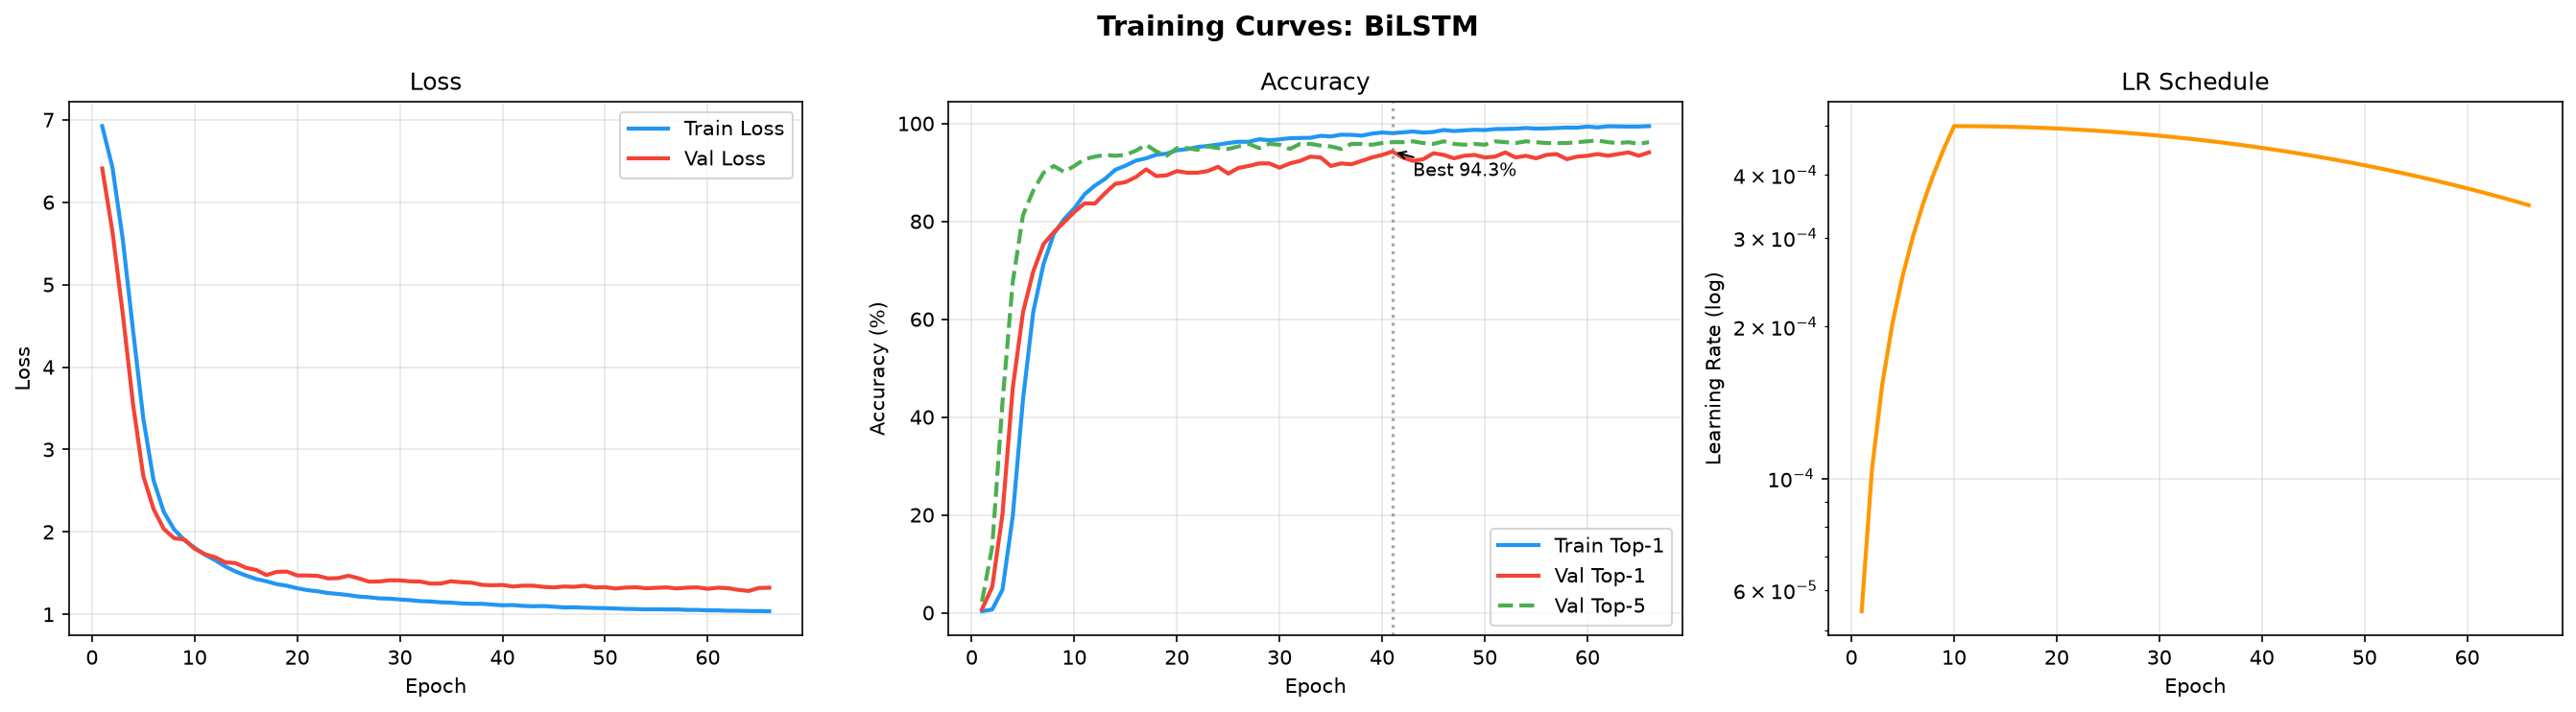

In [27]:
image_path = f'{RESULTS_DIR}/exp_bilstm/training_curves.png'
display(Image(filename=image_path))

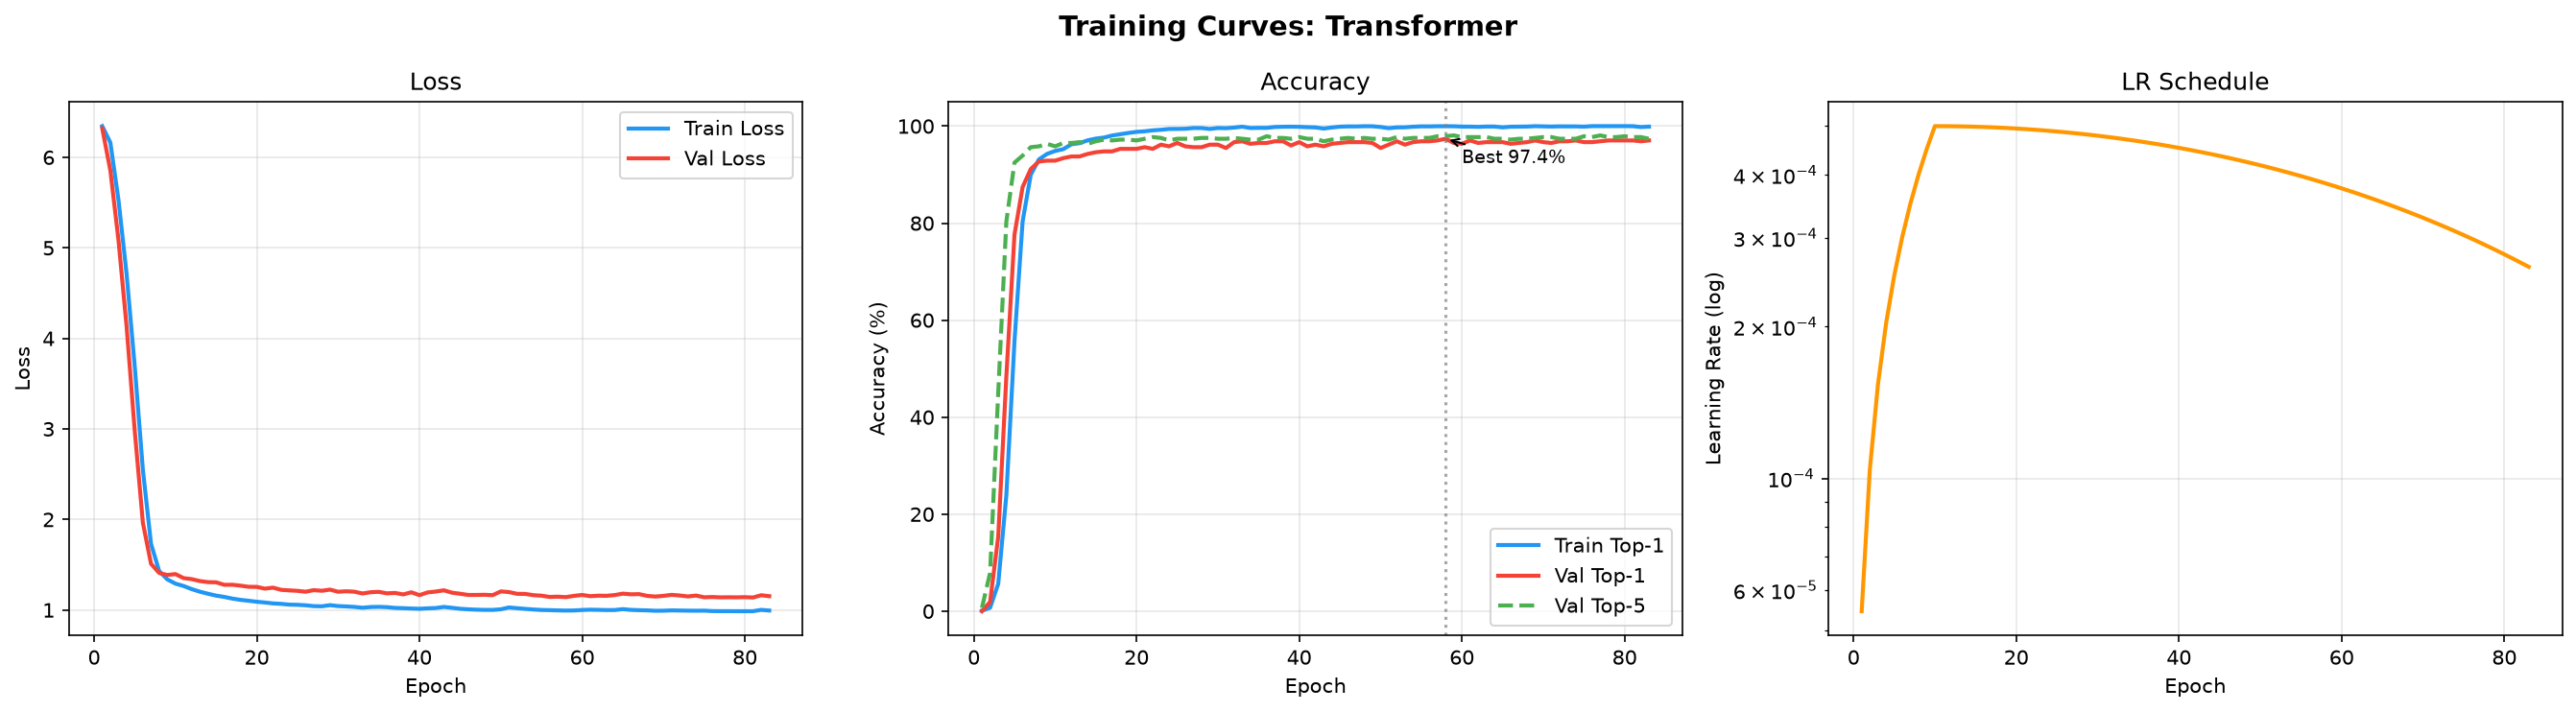

In [28]:
image_path = f'{RESULTS_DIR}/exp_transformer/training_curves.png'
display(Image(filename=image_path))

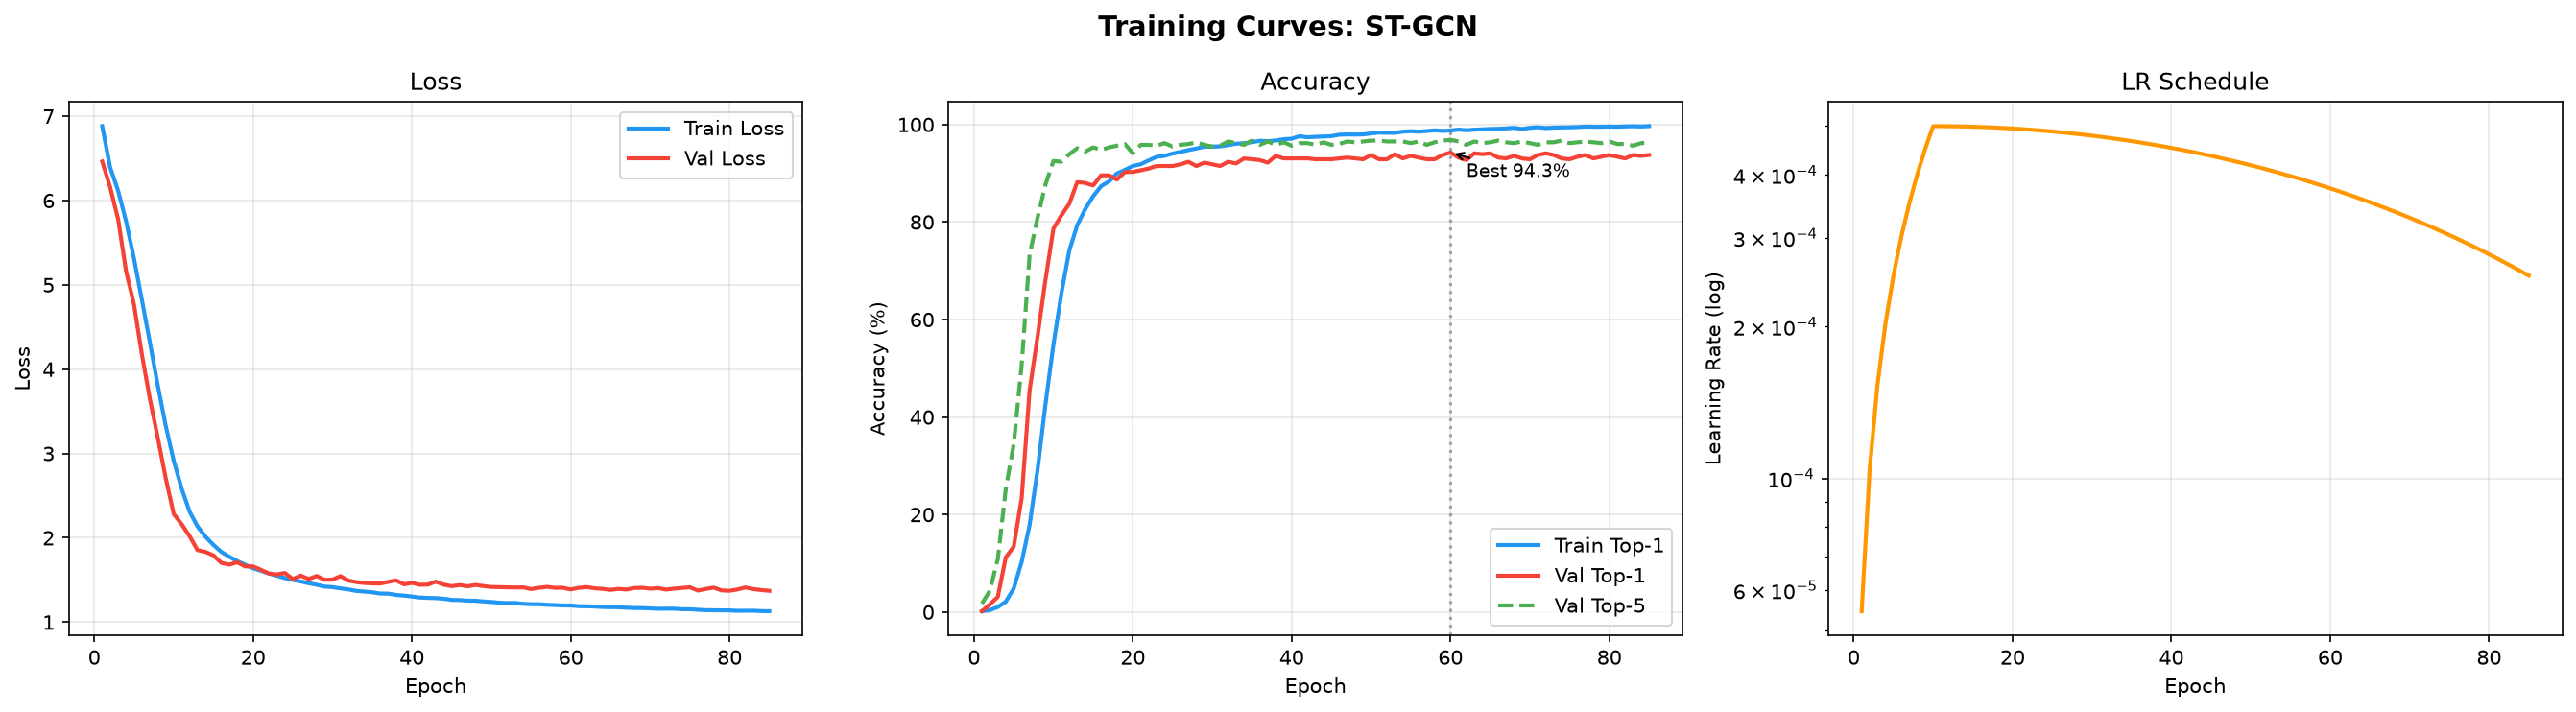

In [29]:
image_path = f'{RESULTS_DIR}/exp_stgcn/training_curves.png'
display(Image(filename=image_path))

### Model Comparison

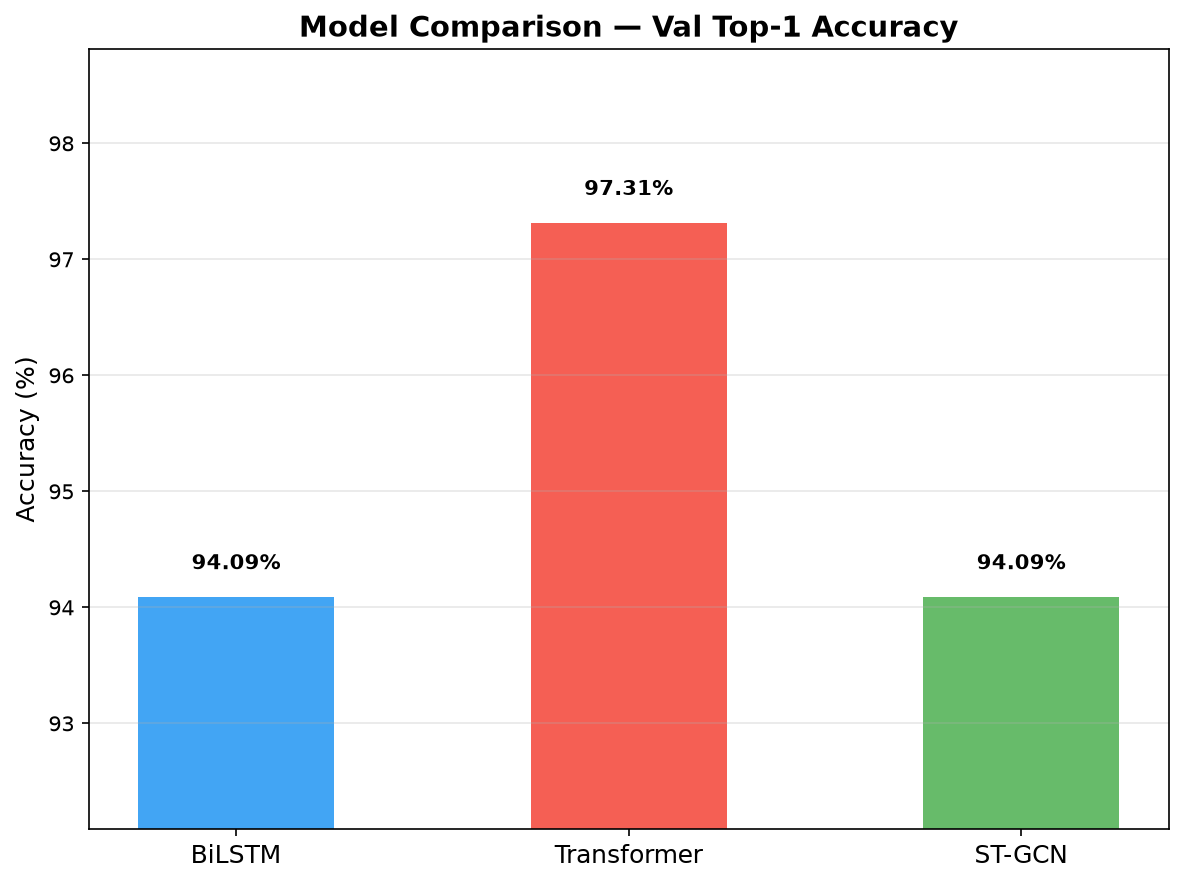

In [30]:
image_path = f'{RESULTS_DIR}/comparison_val.png'
display(Image(filename=image_path, width=400, height=200))

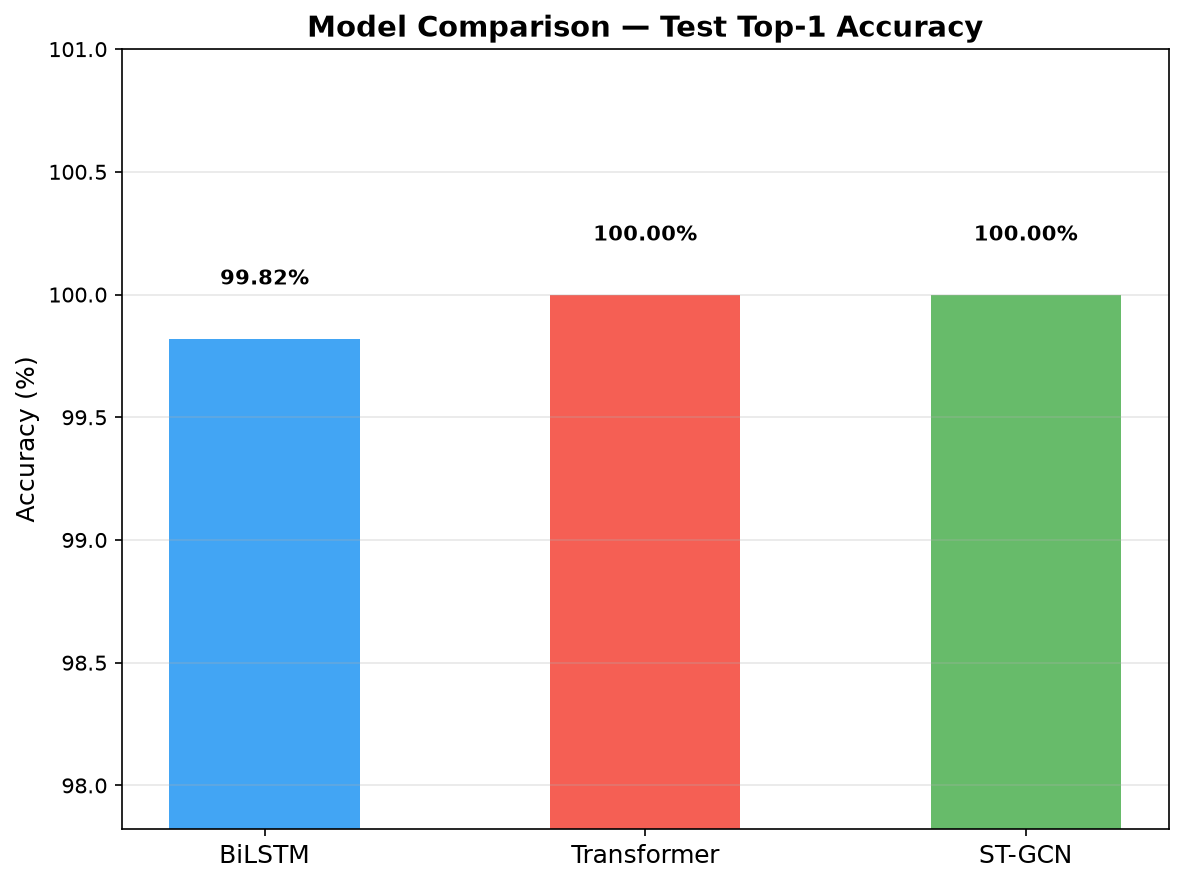

In [31]:
image_path = f'{RESULTS_DIR}/comparison_test.png'
display(Image(filename=image_path, width=400, height=200))

In [32]:
!python {SCRIPTS_DIR}/compare_results.py

          Model Performance Comparison (Myanmar Sign Language)
Model         | Val Top-1 Val Top-5   Val F1 | Test Top-1 Test Top-5  Test Prec  Test Rec  Test F1
──────────────────────────────────────────────────────────────────────────────────────────────────
Bi-LSTM       |    94.09%    96.06%   92.20% |     99.82%    100.00%     99.72%    99.82%   99.75%
Transformer   |    97.31%    97.85%   96.30% |    100.00%    100.00%    100.00%   100.00%  100.00%
ST-GCN        |    94.09%    96.77%   92.62% |    100.00%    100.00%    100.00%   100.00%  100.00%


{
  "split": "test",
  "num_samples": 558,
  "num_classes": 541,
  "top1_accuracy": 0.9982078853046595,
  "top5_accuracy": 1.0,
  "precision_macro": 0.9972273567467652,
  "recall_macro": 0.9981515711645101,
  "f1_macro": 0.9975354282193468,
  "precision_weighted": 0.9973118279569892,
  "recall_weighted": 0.9982078853046595,
  "f1_weighted": 0.9976105137395459
}

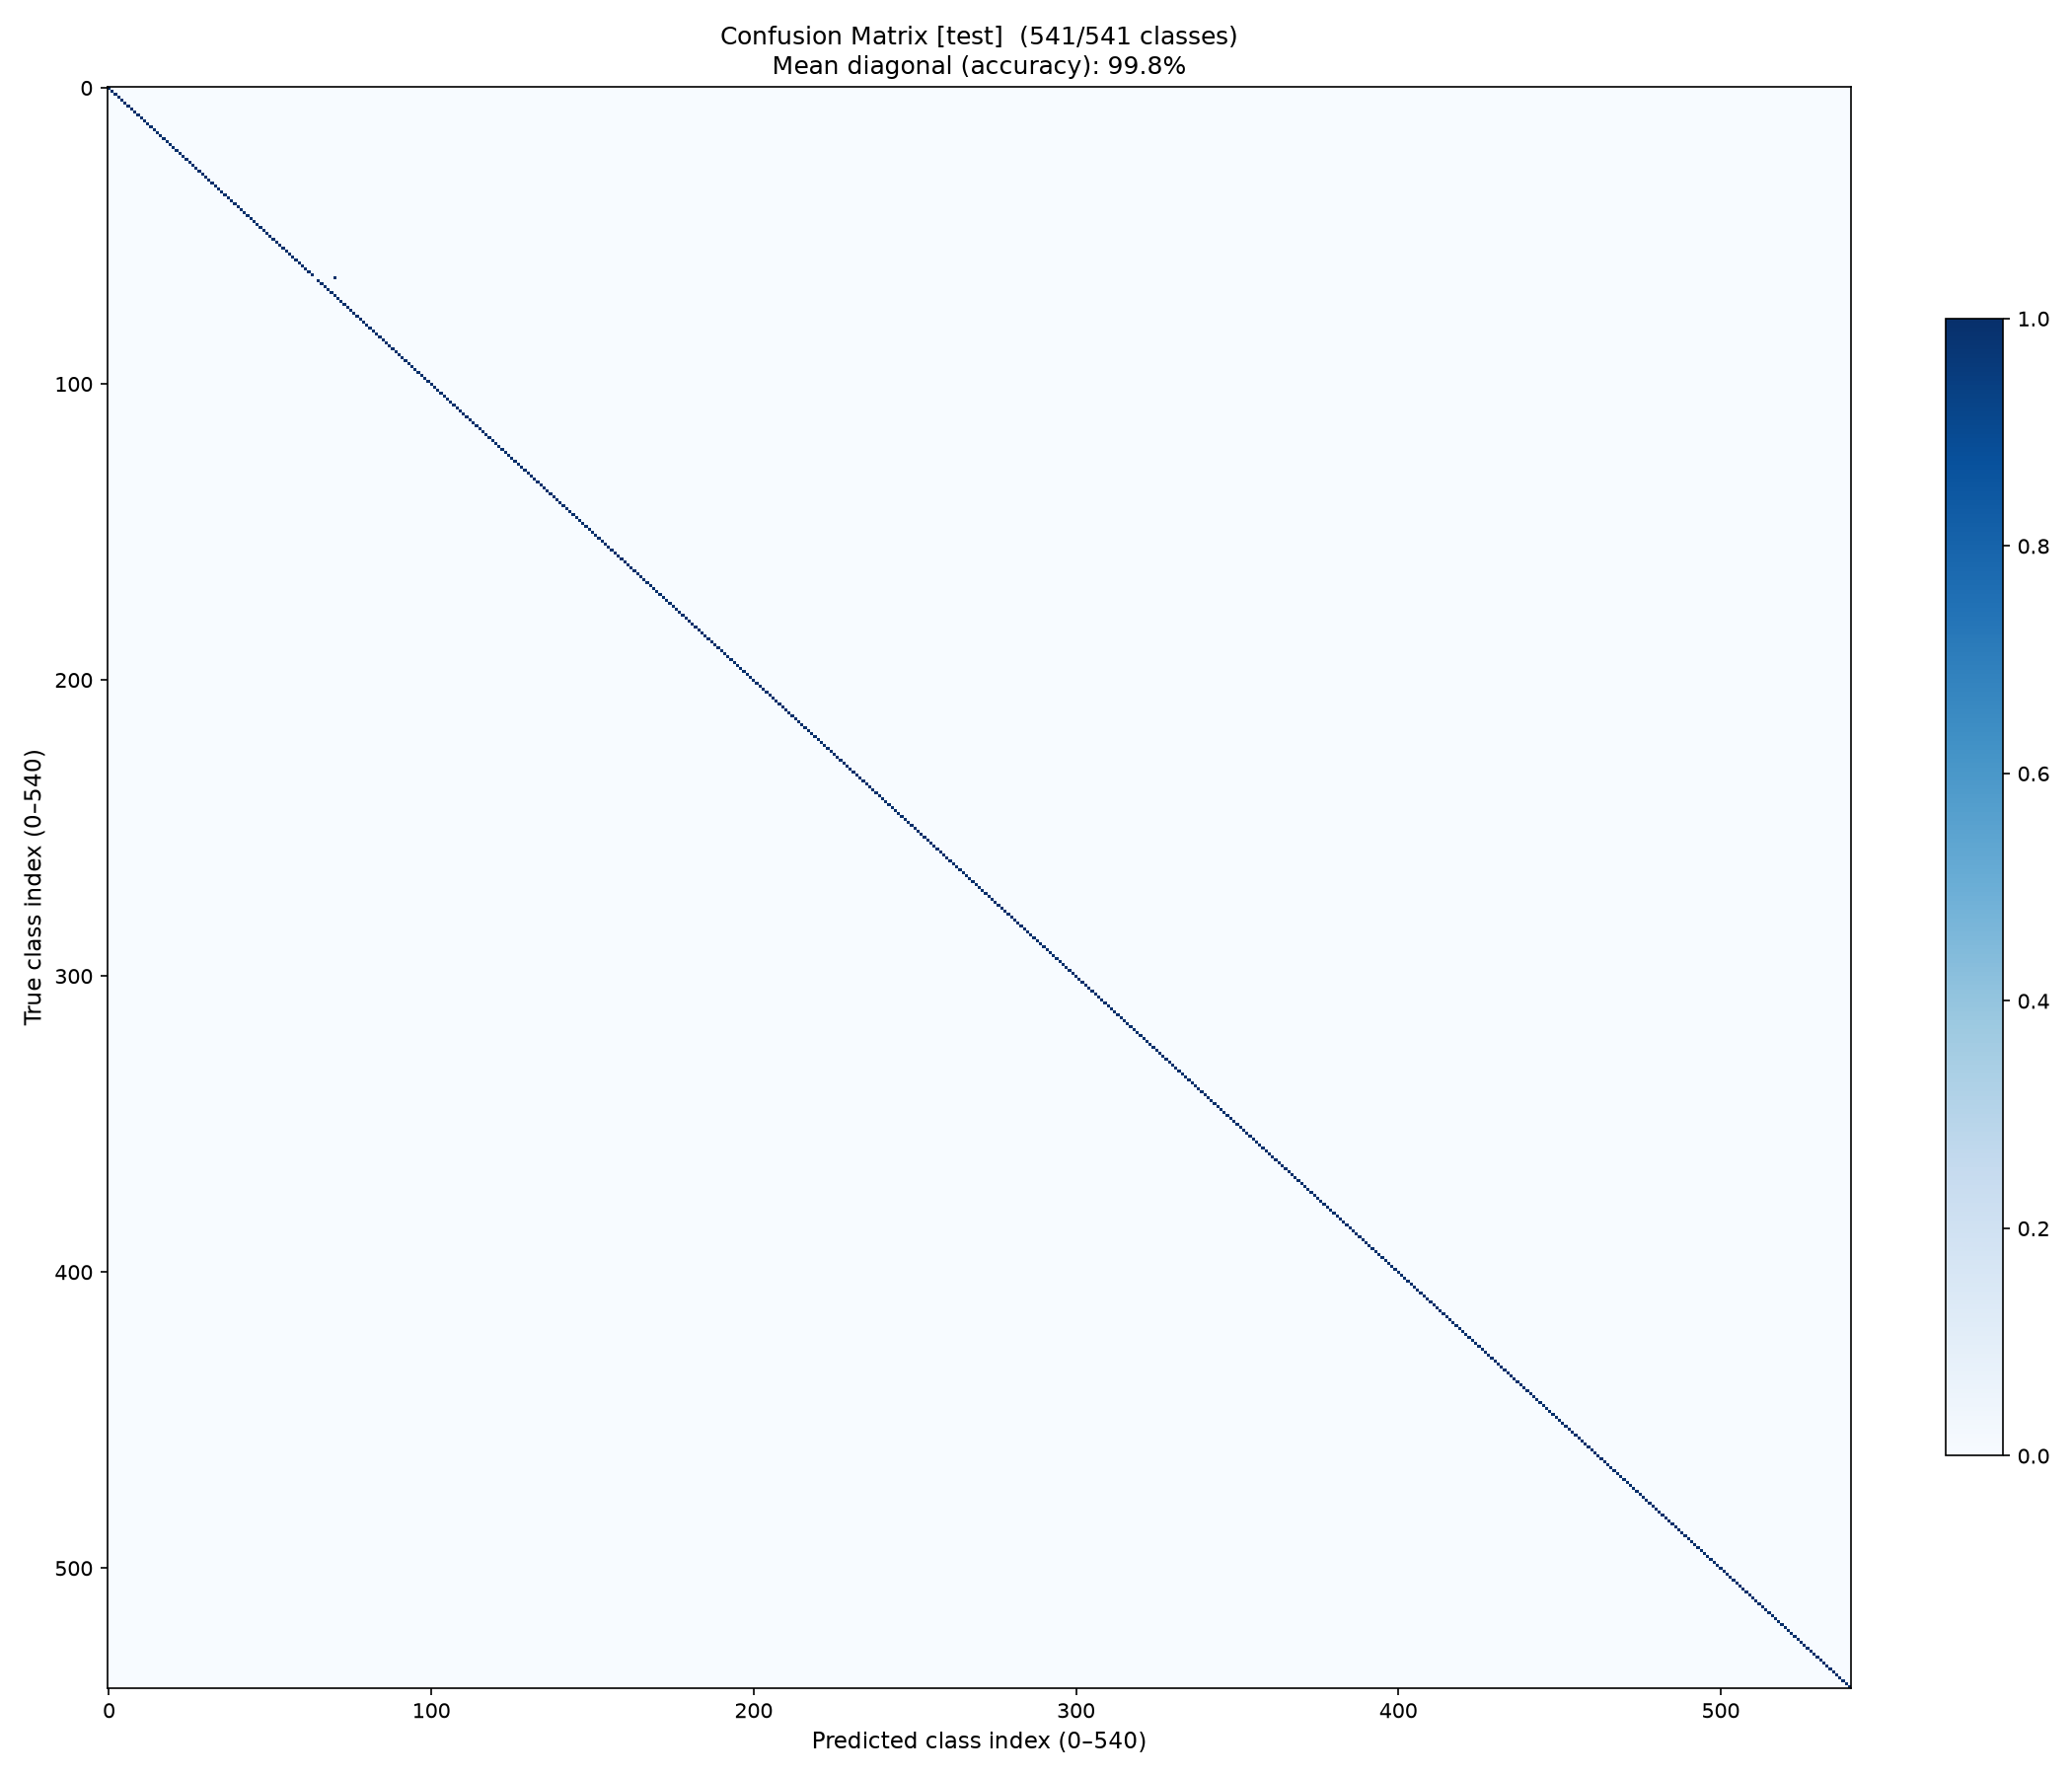

In [33]:
# BiLSTM
!cat {RESULTS_DIR}/exp_bilstm/evaluation/metrics_test.json
display(Image(filename=f'{RESULTS_DIR}/exp_bilstm/evaluation/confusion_matrix_test.png', width=400, height=200))

{
  "split": "test",
  "num_samples": 558,
  "num_classes": 541,
  "top1_accuracy": 1.0,
  "top5_accuracy": 1.0,
  "precision_macro": 1.0,
  "recall_macro": 1.0,
  "f1_macro": 1.0,
  "precision_weighted": 1.0,
  "recall_weighted": 1.0,
  "f1_weighted": 1.0
}

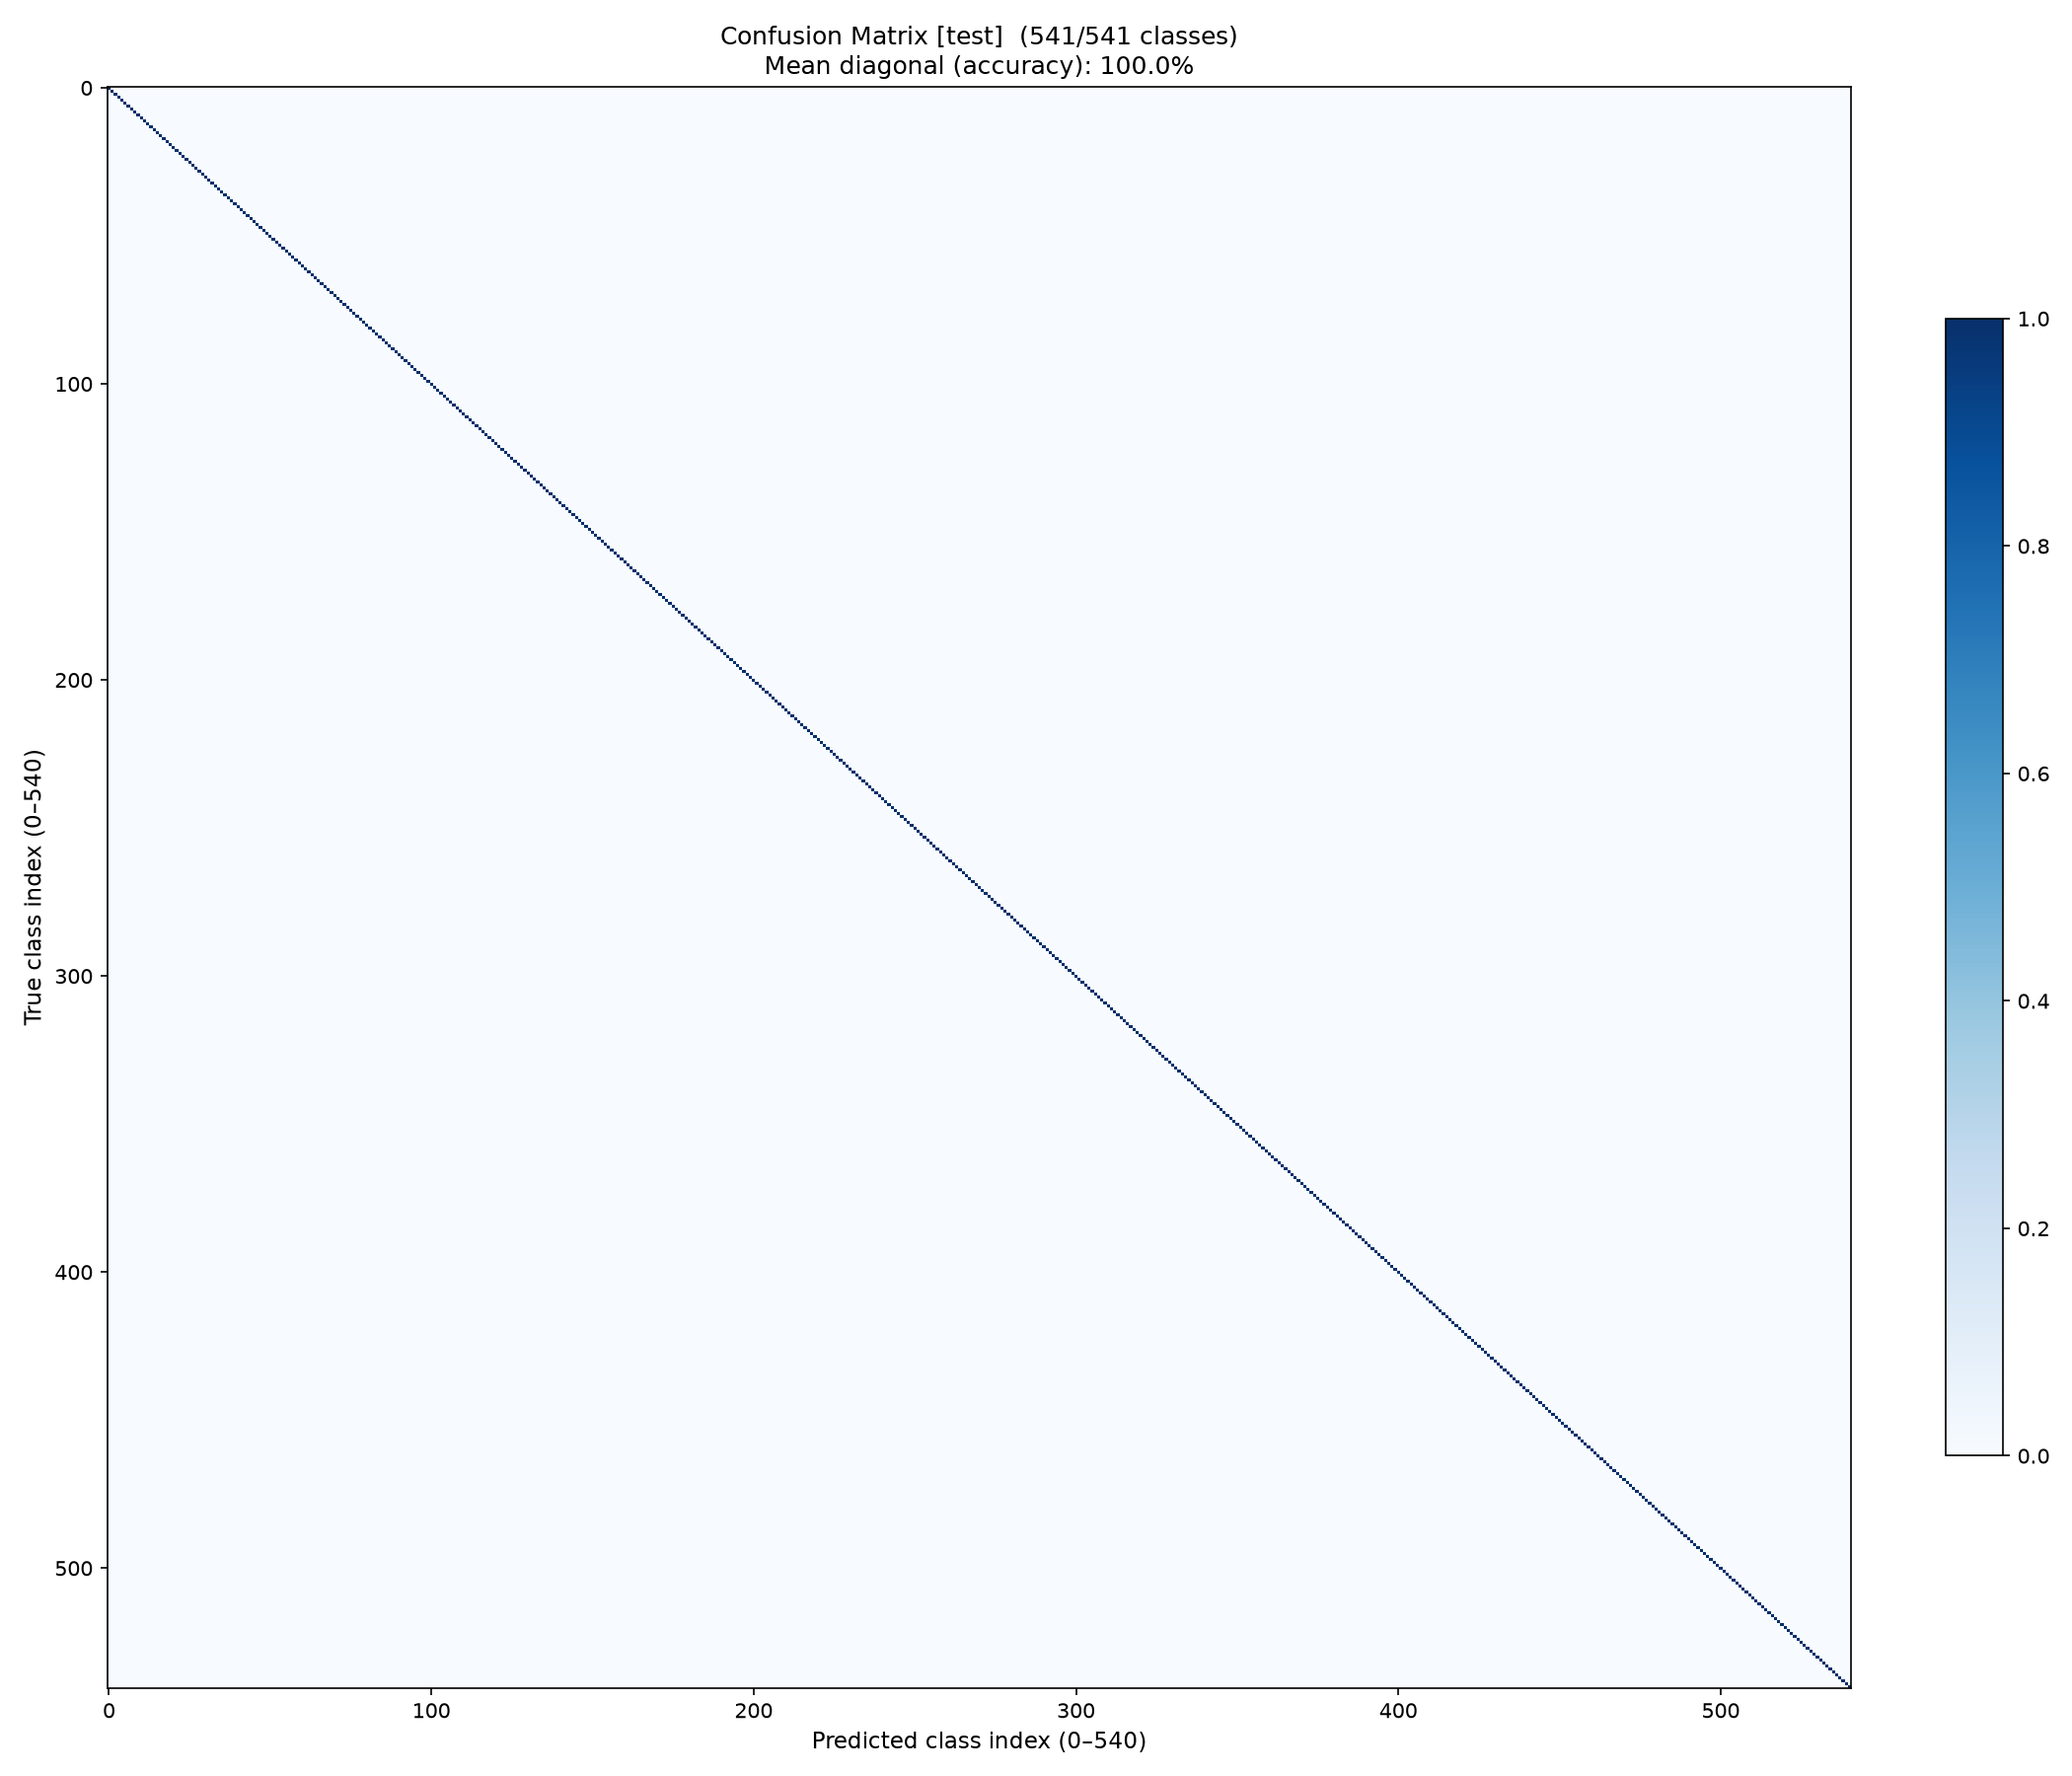

In [34]:
# Transformer
!cat {RESULTS_DIR}/exp_transformer/evaluation/metrics_test.json
display(Image(filename=f'{RESULTS_DIR}/exp_transformer/evaluation/confusion_matrix_test.png', width=400, height=200))

{
  "split": "test",
  "num_samples": 558,
  "num_classes": 541,
  "top1_accuracy": 1.0,
  "top5_accuracy": 1.0,
  "precision_macro": 1.0,
  "recall_macro": 1.0,
  "f1_macro": 1.0,
  "precision_weighted": 1.0,
  "recall_weighted": 1.0,
  "f1_weighted": 1.0
}

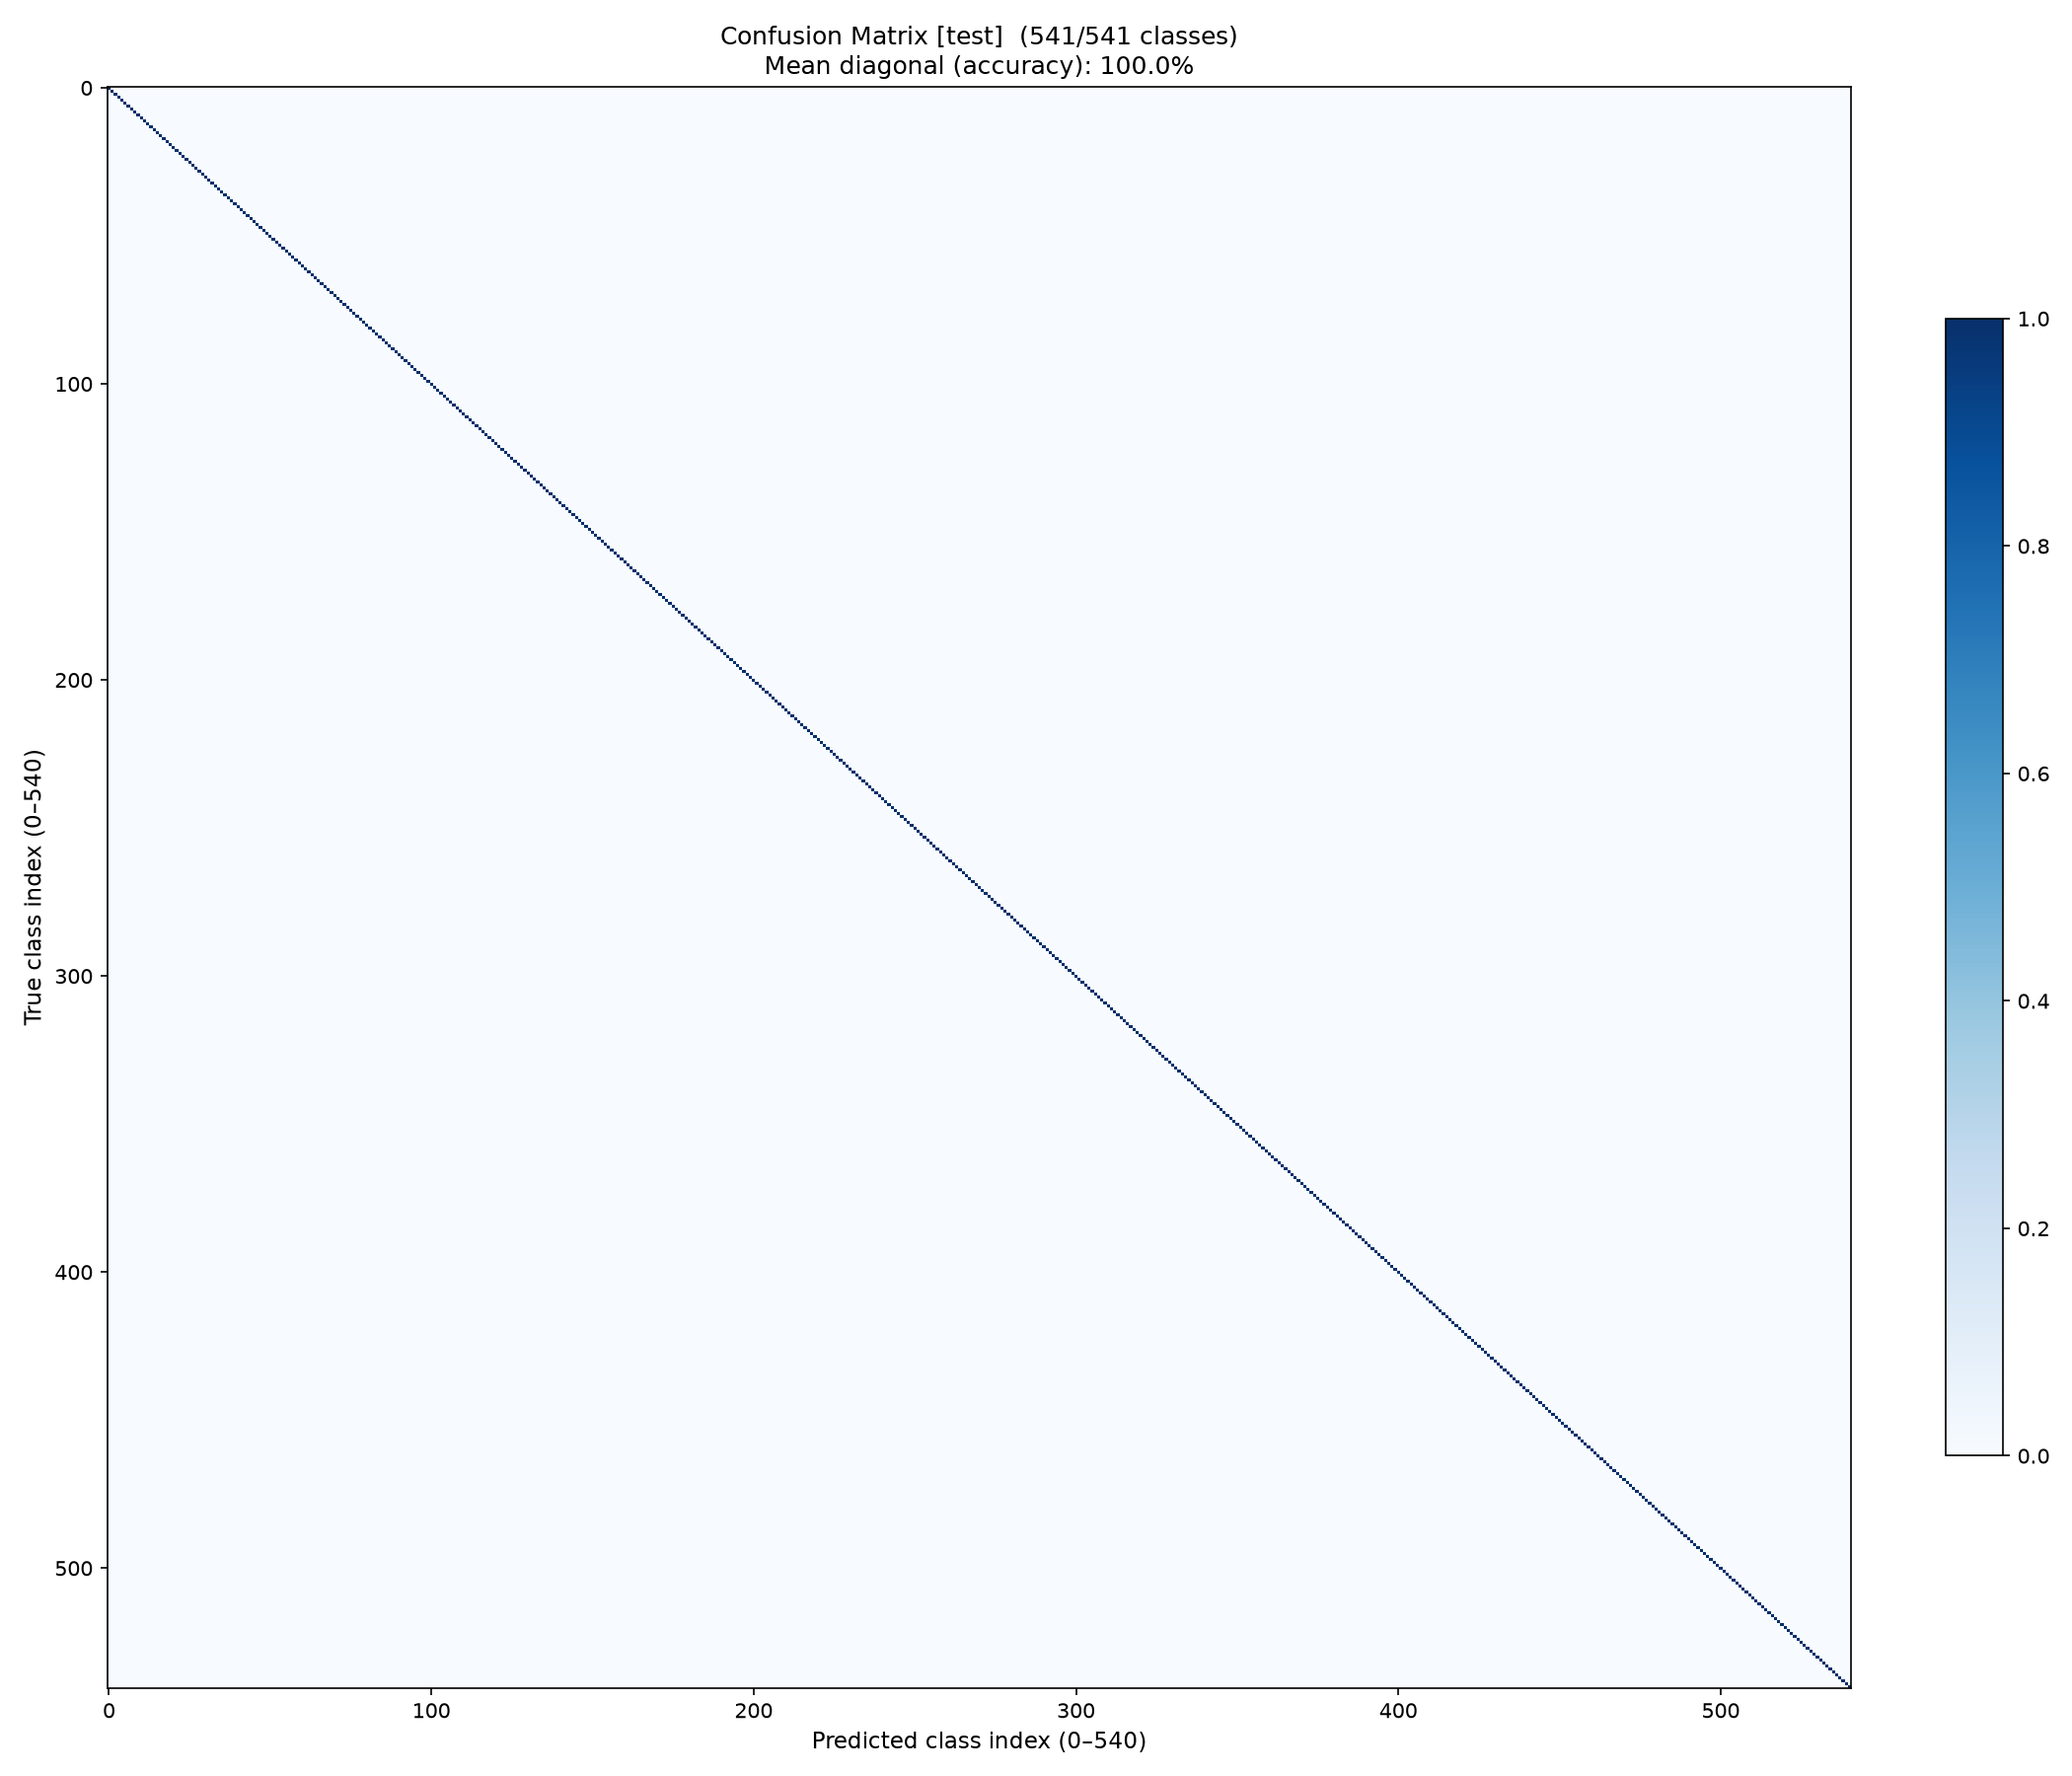

In [35]:
# ST-GCN
!cat {RESULTS_DIR}/exp_stgcn/evaluation/metrics_test.json
display(Image(filename=f'{RESULTS_DIR}/exp_stgcn/evaluation/confusion_matrix_test.png', width=400, height=200))

## 8. Inference

To test models, sample videos must first be placed in the designated directory. In addition, the `08_infer.sh` script must be manually edited before each test run to set the `MODEL` and `EXP` variables to one of the following values:

1.
    ```bash
    MODEL="bilstm"
    EXP="exp_bilstm"
    ```

2.
    ```bash
    MODEL="transformer"
    EXP="exp_transformer"
    ```

3.
    ```bash
    MODEL="stgcn"
    EXP="exp_stgcn"
    ```

In [36]:
INFER_SOURCE = f'{DATA_DIR}/sample4infer'
!ls {INFER_SOURCE}

idx20-101.mp4  idx20-201.mp4  idx20-301.mp4  idx20-401.mp4  Idx20-501.mp4


### Inference with Single Video

In [37]:
Video(f"{INFER_SOURCE}/idx20-101.mp4", width=600)

The MSL gloss of the chosen video above is "ဖုန်းဆက် 199".

In [38]:
# BiLSTM
!time bash {SCRIPTS_DIR}/08_infer.sh video {INFER_SOURCE}/idx20-101.mp4

 MSL Sign Language Inference
 Mode       : video
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/idx20-101.mp4
 Checkpoint : results/exp_bilstm/checkpoints/best.pth

2026-06-20 11:26:51 | INFO     | infer | Loaded bilstm from results/exp_bilstm/checkpoints/best.pth
I0000 00:00:1781929611.513887   91875 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929611.536546   91946 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781929611.560810   91875 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929611.568591   91961 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781929611.754441   91951 inference_feedback_manager.cc:114] Feedba

In [39]:
# Transformer
!time bash {SCRIPTS_DIR}/08_infer.sh video {INFER_SOURCE}/idx20-101.mp4

 MSL Sign Language Inference
 Mode       : video
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/idx20-101.mp4
 Checkpoint : results/exp_transformer/checkpoints/best.pth

2026-06-20 11:29:04 | INFO     | infer | Loaded transformer from results/exp_transformer/checkpoints/best.pth
I0000 00:00:1781929744.932584   92035 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929744.937076   92105 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781929744.945812   92035 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929744.953848   92120 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781929745.070515   92115 inference_feedback_manager

In [40]:
# ST-GCN
!time bash {SCRIPTS_DIR}/08_infer.sh video {INFER_SOURCE}/idx20-101.mp4

 MSL Sign Language Inference
 Mode       : video
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/idx20-101.mp4
 Checkpoint : results/exp_stgcn/checkpoints/best.pth

2026-06-20 11:30:05 | INFO     | infer | Loaded stgcn from results/exp_stgcn/checkpoints/best.pth
I0000 00:00:1781929805.229074   92194 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929805.231450   92262 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781929805.237631   92194 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781929805.239878   92277 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781929805.297033   92264 inference_feedback_manager.cc:114] Feedback 

### Inference with Multiple Videos

Sample videos:
- `data/sample4infer/idx20-101.mp4` $\rightarrow$ "ဖုန်းဆက် 199"
- `data/sample4infer/idx20-201.mp4` $\rightarrow$ "ကိုက် မြွေ အဆိပ်ရှိ ဆိုး"
- `data/sample4infer/idx20-301.mp4` $\rightarrow$ "ဖန်ကွဲစ ရှမိပြီး သွေးတွေတအားထွက်နေ"
- `data/sample4infer/idx20-401.mp4` $\rightarrow$ "ကျွန်တော် တစ်ကိုယ်လုံး ကိုက်ခဲနေတယ်"
- `data/sample4infer/idx20-501.mp4` $\rightarrow$ "ပလာစတာ တစ်ခု လိုချင်လို့ပါ"

In [41]:
# BiLSTM
!time bash {SCRIPTS_DIR}/08_infer.sh batch {INFER_SOURCE}/ # pass batch mode with a directory

 MSL Sign Language Inference
 Mode       : batch
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/
 Checkpoint : results/exp_bilstm/checkpoints/best.pth

2026-06-20 11:57:46 | INFO     | infer | Loaded bilstm from results/exp_bilstm/checkpoints/best.pth
I0000 00:00:1781931466.313163   94650 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931466.316695   94716 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781931466.322825   94650 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931466.325531   94731 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781931466.428936   94724 inference_feedback_manager.cc:114] Feedback manager re

In [42]:
# Transformer
!time bash {SCRIPTS_DIR}/08_infer.sh batch {INFER_SOURCE}/ # pass batch mode with a directory

 MSL Sign Language Inference
 Mode       : batch
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/
 Checkpoint : results/exp_transformer/checkpoints/best.pth

2026-06-20 11:59:49 | INFO     | infer | Loaded transformer from results/exp_transformer/checkpoints/best.pth
I0000 00:00:1781931589.328171   94965 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931589.333560   95033 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781931589.341367   94965 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931589.344697   95048 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781931589.420995   95034 inference_feedback_manager.cc:114] Feed

In [43]:
# ST-GCN
!time bash {SCRIPTS_DIR}/08_infer.sh batch {INFER_SOURCE}/ # pass batch mode with a directory

 MSL Sign Language Inference
 Mode       : batch
 Input      : /home/lawun330/Desktop/myanmar-sign-language-recognition/data/sample4infer/
 Checkpoint : results/exp_stgcn/checkpoints/best.pth

2026-06-20 12:03:47 | INFO     | infer | Loaded stgcn from results/exp_stgcn/checkpoints/best.pth
I0000 00:00:1781931827.350975   95480 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931827.355527   95544 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
I0000 00:00:1781931827.370633   95480 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781931827.378275   95559 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 630 (CFL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781931827.569029   95551 inference_feedback_manager.cc:114] Feedback manager requi